In [14]:
# Load all necessary modules
import scanpy as sc
import matplotlib.pyplot as plt
import anndata as ad
import numpy as np
import pandas as pd
import decipher as dc
import scipy.sparse as sp
import scipy.stats as stats


In [3]:
# Import necessary h5ad files
adata_tumor_dc = sc.read_h5ad('trained_models/adata_tumor_subset_decipher.h5ad')
adata_tumor_full = sc.read_h5ad('trained_models/adata_tumor_full_decipher.h5ad')

# Import gene signatures for undifferentiated and differentiated cells
gene_sigs_df = pd.read_excel('/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/Data/tumor_differentiation_markers.xlsx', sheet_name = 'undiff v diff markers NC')
undiff_sigs = gene_sigs_df.loc[:,'undiff']
diff_sigs = gene_sigs_df.loc[:,'diff']

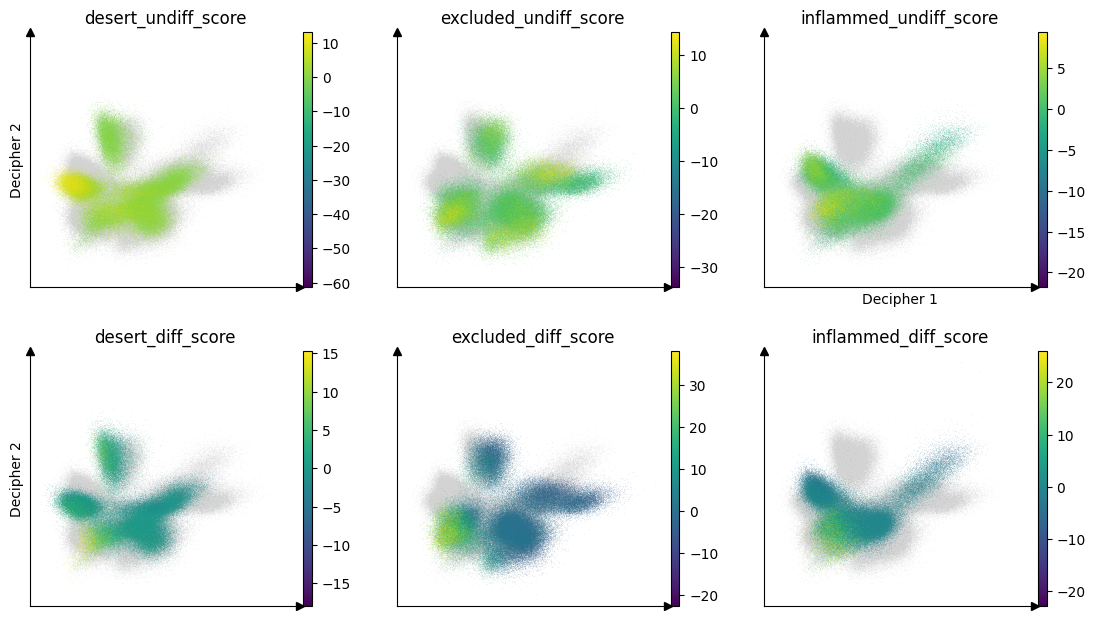

In [ ]:
# Define groups as inflamed, excluded, and desert categories
groups = adata_tumor_full.obs['ex_group'].cat.categories

# For loop to iterate over each category
for g in groups:
    # sc.tl.score_genes can't compute scores per group, so we need workaround
    # Subset for each category with mask
    mask = adata_tumor_full.obs['ex_group'] == g
    adata_group = adata_tumor_full[mask].copy()

    # Calculate average expression of undiff and diff gene signatures by subtracting mean expression from reference set
    # Add scores into new columns in adata_group.obs
    sc.tl.score_genes(adata_group, gene_list = undiff_sigs, score_name = 'undiff_scores')
    sc.tl.score_genes(adata_group, gene_list = diff_sigs, score_name = 'diff_scores')

    # Permanentely add into .loc
    adata_tumor_full.obs.loc[mask, f'{g}_undiff_score'] = adata_group.obs['undiff_scores'].values
    adata_tumor_full.obs.loc[mask, f'{g}_diff_score'] = adata_group.obs['diff_scores'].values

# Plot
color_list = [f'{g}_undiff_score' for g in groups] + [f'{g}_diff_score' for g in groups]
dc.pl.decipher(adata_tumor_full, color = color_list, ncols = 3)
plt.show()


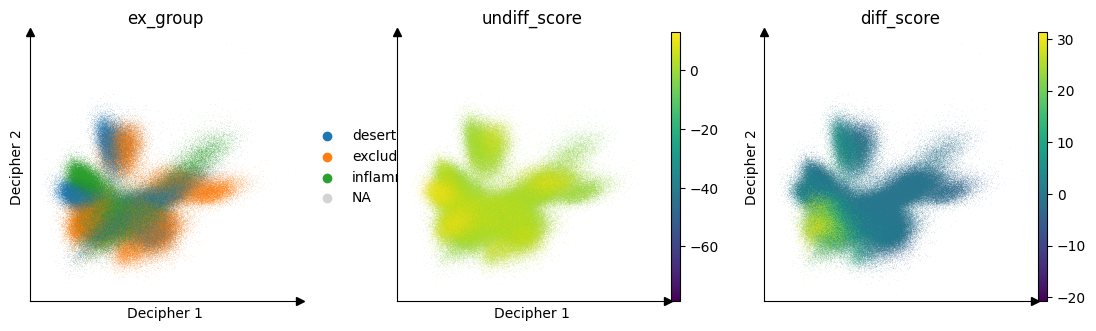

In [ ]:
# Score relative to all cells. Otherwise, we can't compare across groups
sc.tl.score_genes(adata_tumor_full, gene_list=undiff_sigs, score_name='undiff_score')
sc.tl.score_genes(adata_tumor_full, gene_list=diff_sigs, score_name='diff_score')

# Plot
dc.pl.decipher(adata_tumor_full, color=['ex_group', 'undiff_score', 'diff_score'], ncols=3)
plt.show()

2026-03-22 04:53:51,126 | INFO : Clustering cells using scanpy Leiden algorithm.
2026-03-22 04:53:51,141 | INFO : Step 1: Computing neighbors with `sc.pp.neighbors`, with the representation decipher_z.
2026-03-22 04:54:31,172 | INFO : Step 2: Computing clusters with `sc.tl.leiden`, and resolution 1.0.
/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher/decipher/tools/trajectory_inference.py:225: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(
2026-03-22 05:16:59,096 | INFO : Added `.obs['decipher_clusters']`: the cluster labels.


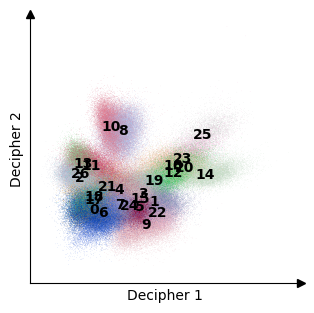

In [17]:
# Create decipher clusters
dc.tl.cell_clusters(adata_tumor_full)
dc.pl.decipher(adata_tumor_full, color = ['decipher_clusters'],legend_loc='on data')

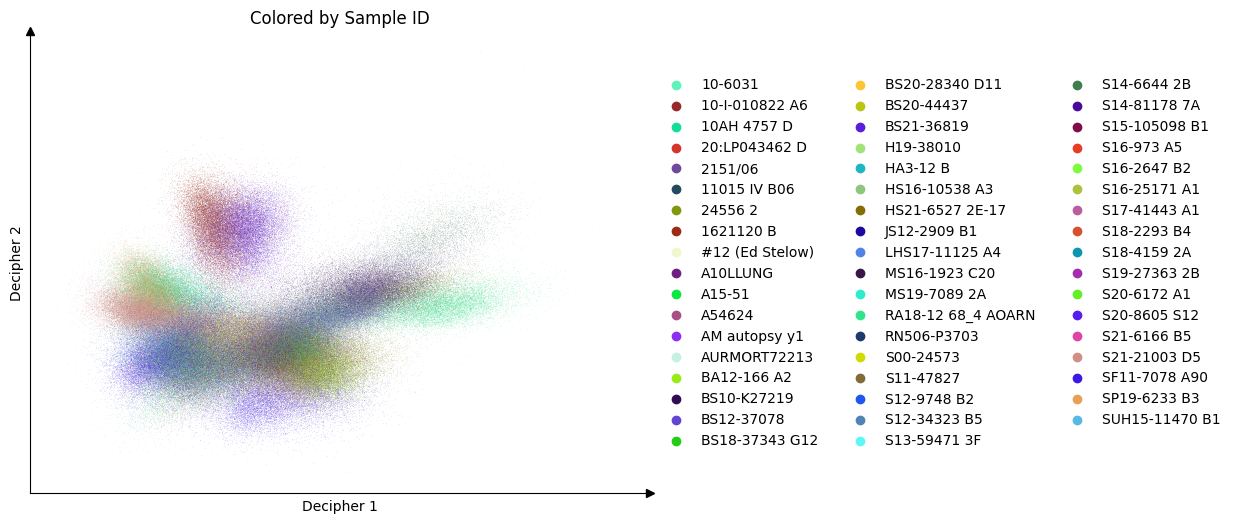

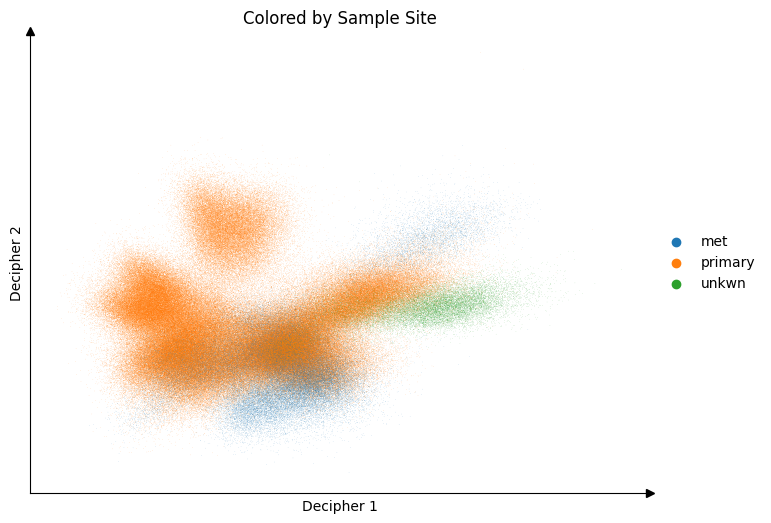

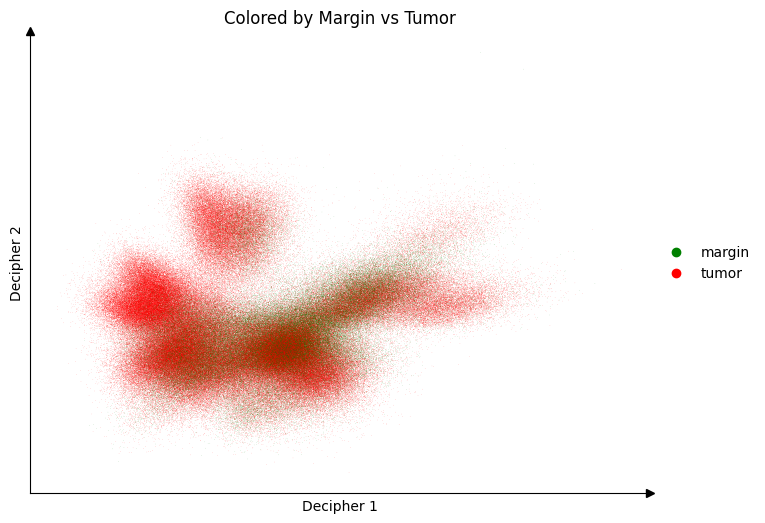

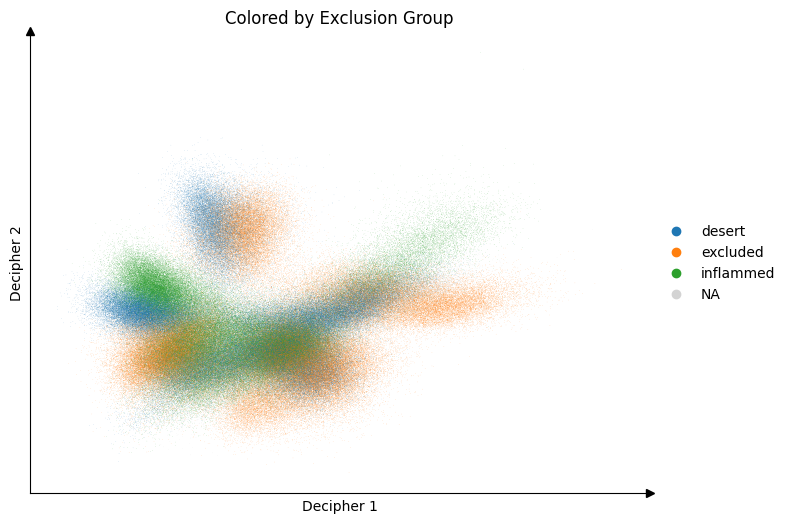

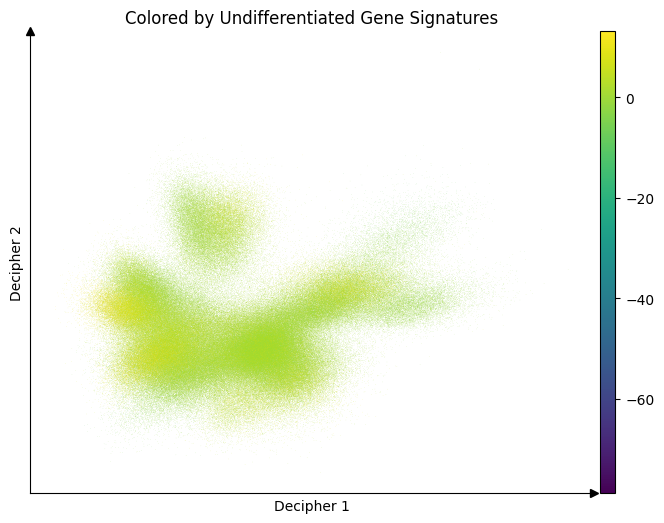

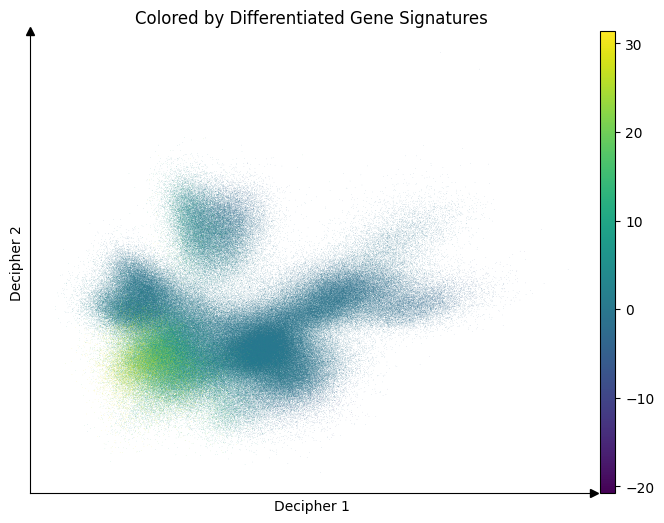

In [43]:
dc.pl.decipher(adata_tumor_full, color=['sample_id'], legend_loc='right margin', figsize=(8, 6), title='Colored by Sample ID')
plt.show()

dc.pl.decipher(adata_tumor_full, color=['sample site: primary vs met'], legend_loc='right margin', figsize=(8, 6),title='Colored by Sample Site')
plt.show()

dc.pl.decipher(adata_tumor_full, color=['sample_type'], legend_loc='right margin', figsize=(8, 6),title = 'Colored by Margin vs Tumor')
plt.show()

dc.pl.decipher(adata_tumor_full, color=['ex_group'], legend_loc='right margin', figsize=(8,6),title='Colored by Exclusion Group')
plt.show()

dc.pl.decipher(adata_tumor_full, color=['undiff_score'], legend_loc='right margin', figsize=(8,6),title='Colored by Undifferentiated Gene Signatures')
plt.show()

dc.pl.decipher(adata_tumor_full, color=['diff_score'], legend_loc='right margin', figsize=(8,6),title='Colored by Differentiated Gene Signatures')
plt.show()

In [36]:
# Filter unknown cells to identify any trends
unknown_obs = adata_tumor_full.obs[adata_tumor_full.obs['sample site: primary vs met'] == 'unkwn']

print(unknown_obs['sample_id'].value_counts())
print(unknown_obs['TMA'].value_counts())

print(pd.crosstab(unknown_obs['sample_id'], unknown_obs['TMA']))

sample_id
RA18-12 68_4 AOARN    19089
#12 (Ed Stelow)         248
10-6031                   0
S16-2647 B2               0
RN506-P3703               0
S00-24573                 0
S11-47827                 0
S12-9748 B2               0
S12-34323 B5              0
S13-59471 3F              0
S14-6644 2B               0
S14-81178 7A              0
S15-105098 B1             0
S16-973 A5                0
S16-25171 A1              0
MS16-1923 C20             0
S17-41443 A1              0
S18-2293 B4               0
S18-4159 2A               0
S19-27363 2B              0
S20-6172 A1               0
S20-8605 S12              0
S21-6166 B5               0
S21-21003 D5              0
SF11-7078 A90             0
SP19-6233 B3              0
MS19-7089 2A              0
LHS17-11125 A4            0
10-I-010822 A6            0
AURMORT72213              0
10AH 4757 D               0
20:LP043462 D             0
2151/06                   0
11015 IV B06              0
24556 2                   0
1621120 B 

As suspected, cells corresponding to Unknown Sample Site all come from select few patient (two in this case).